## 1) Data Preprocessing

Steps for cleaning and preparing the dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
from sklearn.metrics import precision_recall_curve, roc_curve, auc, accuracy_score
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [2]:
sample_submission_data = pd.read_csv("sample_submission.csv")
pub_priv_data = pd.read_csv("public_private_X.csv")
train_X_data = pd.read_csv("train_X.csv")
train_y_data = pd.read_csv("train_y.csv")
train_data = pd.merge(train_X_data, train_y_data)

In [3]:
# Check missing values to see if need to impute
print("Missing values Train:\n", train_data.isnull().sum())
print("Missing values Test:\n", pub_priv_data.isnull().sum())

Missing values Train:
 ID                                         0
DIVISION_NUMBER                            0
PRODUCT_NUMBER                             0
PURCHASE_ORDER_DUE_DATE                    0
COMPANY_VENDOR_NUMBER                      0
SHIP_FROM_VENDOR                           0
ORDER_DATE                                 0
ORDER_DAY_OF_WEEK                          0
PRODUCT_CLASSIFICATION                     0
PURCHASE_ORDER_TYPE                        0
DISTANCE_IN_MILES                          0
DIVISION_CODE                              0
PURCHASE_FROM_VENDOR                       0
AVERAGE_PRODUCT_ORDER_QUANTITY_MARKET      0
ORDER_QUANTITY_DEVIATION                   0
TRANSIT_LEAD_TIME                          0
PURCHASING_LEAD_TIME                       0
DAYS_BETWEEN_ORDER_AND_DUE_DATE            0
GIVEN_TIME_TO_LEAD_TIME_RATIO              0
DUE_DATE_WEEKDAY                           0
PRODUCT_MARKET                             0
RESERVABLE_INDICATOR            

In [4]:
# Correlations with target variable to determine feature selection
data_dummies = pd.get_dummies(train_data, drop_first=True)
correlations = data_dummies.corr()['ON_TIME_AND_COMPLETE'].sort_values(ascending=False)

print(correlations.head(20))
print(correlations.tail(20))

ON_TIME_AND_COMPLETE                  1.000000
PRODUCT_CLASSIFICATION                0.266281
COMPANY_VENDOR_NUMBER                 0.238684
PURCHASE_FROM_VENDOR                  0.199145
GIVEN_TIME_TO_LEAD_TIME_RATIO         0.101843
AVERAGE_DAILY_DEMAND_CASES            0.091601
SHIP_FROM_VENDOR                      0.068787
PURCHASE_ORDER_DUE_DATE_2014-06-28    0.066176
PURCHASE_ORDER_DUE_DATE_2014-08-09    0.060566
PURCHASE_ORDER_DUE_DATE_2014-06-18    0.057394
ORDER_DATE_2014-08-15                 0.056005
PURCHASE_ORDER_DUE_DATE_2014-09-18    0.055720
ORDER_DATE_2014-07-18                 0.052362
PURCHASE_ORDER_DUE_DATE_2014-07-03    0.050210
PURCHASE_ORDER_DUE_DATE_2014-09-24    0.049891
PURCHASE_ORDER_DUE_DATE_2014-06-25    0.048918
PURCHASE_ORDER_DUE_DATE_2014-07-02    0.045493
PURCHASE_ORDER_DUE_DATE_2014-07-16    0.044813
PURCHASE_ORDER_DUE_DATE_2014-08-04    0.043299
PURCHASE_ORDER_DUE_DATE_2014-06-23    0.041886
Name: ON_TIME_AND_COMPLETE, dtype: float64
PURCHASE_ORDER_DU

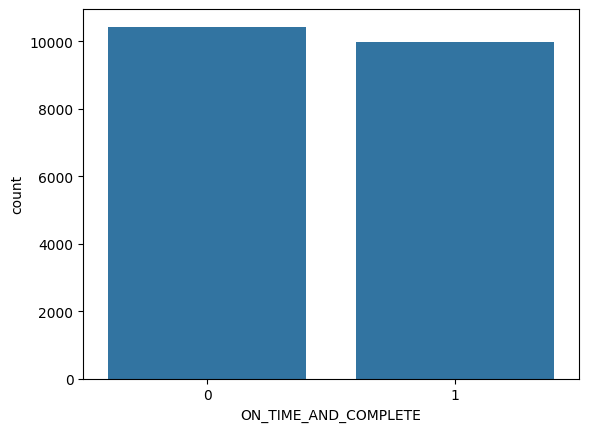

In [5]:
# Visualize distribution of on time and complete
sns.countplot(x = 'ON_TIME_AND_COMPLETE',data = train_data);

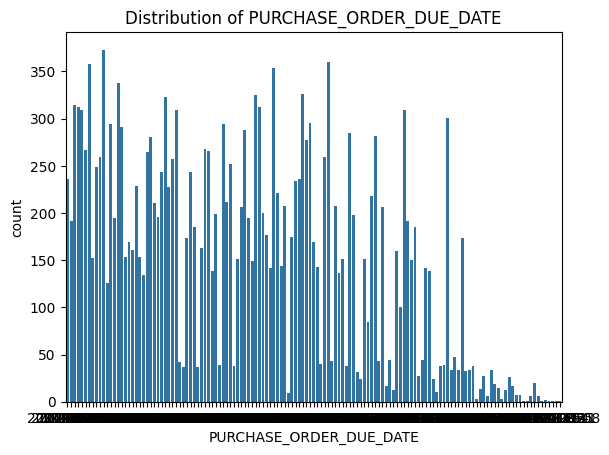

In [6]:
# Plot distribution of PURCHASE_ORDER_DUE_DATE
plt.figure()
sns.countplot(x='PURCHASE_ORDER_DUE_DATE', data=train_data)
plt.title('Distribution of PURCHASE_ORDER_DUE_DATE');

In [7]:
# Look at skewness for potential log transformation or binning
selected_variables = [
    'PRODUCT_CLASSIFICATION', 'PURCHASE_FROM_VENDOR', 'GIVEN_TIME_TO_LEAD_TIME_RATIO',
    'AVERAGE_DAILY_DEMAND_CASES', 'SHIP_FROM_VENDOR', 'AVERAGE_VENDOR_ORDER_CYCLE_DAYS',
    'AVERAGE_PRODUCT_ORDER_QUANTITY_MARKET', 'AVERAGE_ORDER_CYCLE_DAYS', 'DISTANCE_IN_MILES',
    'LEAD_TIME_TO_DISTANCE_RATIO'
]

skewed_vars = train_data[selected_variables].select_dtypes(include=[np.number]).columns
skewness = train_data[skewed_vars].apply(skew).sort_values(ascending=False)
print("Skewness:\n", skewness)

Skewness:
 GIVEN_TIME_TO_LEAD_TIME_RATIO            12.999634
AVERAGE_PRODUCT_ORDER_QUANTITY_MARKET    10.062938
LEAD_TIME_TO_DISTANCE_RATIO               7.302515
SHIP_FROM_VENDOR                          1.050264
DISTANCE_IN_MILES                         1.038973
PRODUCT_CLASSIFICATION                   -0.134906
PURCHASE_FROM_VENDOR                     -0.345856
AVERAGE_DAILY_DEMAND_CASES                     NaN
AVERAGE_VENDOR_ORDER_CYCLE_DAYS                NaN
AVERAGE_ORDER_CYCLE_DAYS                       NaN
dtype: float64


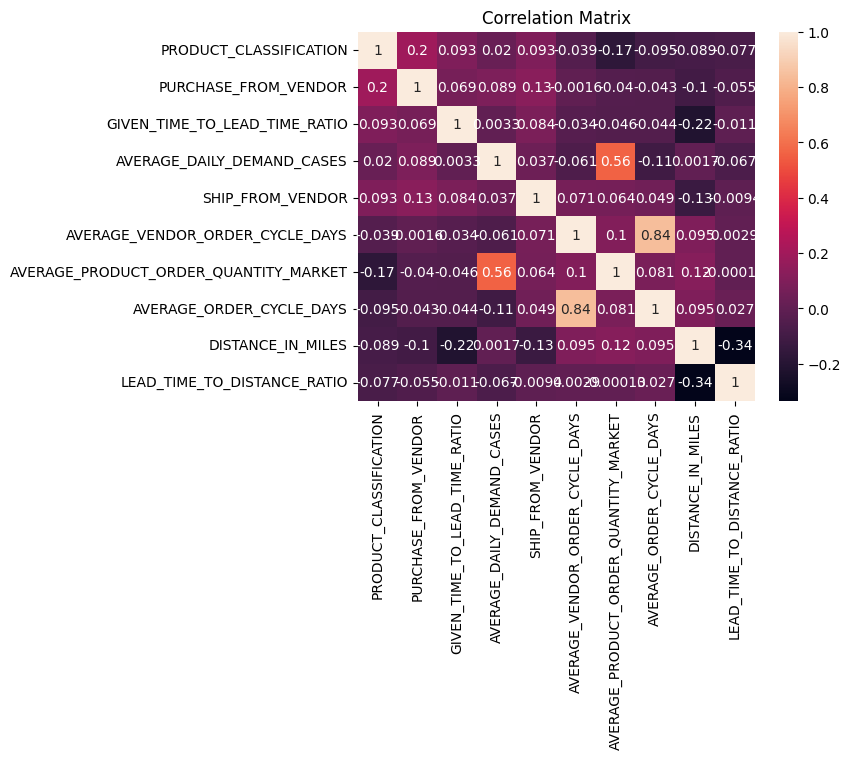

In [8]:
# Look at correlation matrix for multicollinearity or interaction terms
correlation_matrix = train_data[selected_variables].corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix');

In [9]:
# Fill missing values with median
cols_with_missing_data = ["AVERAGE_DAILY_DEMAND_CASES", "AVERAGE_VENDOR_ORDER_CYCLE_DAYS", "AVERAGE_ORDER_CYCLE_DAYS", "AVERAGE_ORDER_CYCLE_CASES"]

for col in cols_with_missing_data:
    train_data.loc[:, col] = train_data[col].fillna(train_data[col].median())
    pub_priv_data.loc[:, col] = pub_priv_data[col].fillna(pub_priv_data[col].median())

## 2) Feature Engineering

Techniques used to create meaningful features

In [10]:
# LOG VARIABLES

# First fix rows with zero and fill with median (will throw an error if not)
train_data.loc[train_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"] <= 0, "GIVEN_TIME_TO_LEAD_TIME_RATIO"] = np.nan
train_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"] = train_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"].fillna(train_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"].median())
pub_priv_data.loc[pub_priv_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"] <= 0, "GIVEN_TIME_TO_LEAD_TIME_RATIO"] = np.nan
pub_priv_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"] = pub_priv_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"].fillna(pub_priv_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"].median())

train_data.loc[train_data["LEAD_TIME_TO_DISTANCE_RATIO"] <= 0, "LEAD_TIME_TO_DISTANCE_RATIO"] = np.nan
train_data["LEAD_TIME_TO_DISTANCE_RATIO"] = train_data["LEAD_TIME_TO_DISTANCE_RATIO"].fillna(train_data["LEAD_TIME_TO_DISTANCE_RATIO"].median())
pub_priv_data.loc[pub_priv_data["LEAD_TIME_TO_DISTANCE_RATIO"] <= 0, "LEAD_TIME_TO_DISTANCE_RATIO"] = np.nan
pub_priv_data["LEAD_TIME_TO_DISTANCE_RATIO"] = pub_priv_data["LEAD_TIME_TO_DISTANCE_RATIO"].fillna(pub_priv_data["LEAD_TIME_TO_DISTANCE_RATIO"].median())

# Create log variables for both training and test sets
train_data["log_time_to_lead"] = np.log(train_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"] + 1e-10)
train_data["log_quantity_market"] = np.log(train_data["AVERAGE_PRODUCT_ORDER_QUANTITY_MARKET"] + 1e-10)
train_data["log_time_dist"] = np.log(train_data["LEAD_TIME_TO_DISTANCE_RATIO"] + 1e-10)
train_data["log_ship_vendor"] = np.log(train_data["SHIP_FROM_VENDOR"] + 1e-10)

pub_priv_data["log_time_to_lead"] = np.log(pub_priv_data["GIVEN_TIME_TO_LEAD_TIME_RATIO"] + 1e-10)
pub_priv_data["log_quantity_market"] = np.log(pub_priv_data["AVERAGE_PRODUCT_ORDER_QUANTITY_MARKET"] + 1e-10)
pub_priv_data["log_time_dist"] = np.log(pub_priv_data["LEAD_TIME_TO_DISTANCE_RATIO"] + 1e-10)
pub_priv_data["log_ship_vendor"] = np.log(pub_priv_data["SHIP_FROM_VENDOR"] + 1e-10)

In [11]:
# Bin purchase order due date variable for both train and test
train_data['PURCHASE_ORDER_DUE_DATE'] = pd.to_datetime(train_data['PURCHASE_ORDER_DUE_DATE'])
train_data['week_of_year'] = train_data['PURCHASE_ORDER_DUE_DATE'].dt.isocalendar().week
train_data['week_of_year'] = train_data['week_of_year'].astype(int)

pub_priv_data['PURCHASE_ORDER_DUE_DATE'] = pd.to_datetime(pub_priv_data['PURCHASE_ORDER_DUE_DATE'])
pub_priv_data['week_of_year'] = pub_priv_data['PURCHASE_ORDER_DUE_DATE'].dt.isocalendar().week
pub_priv_data['week_of_year'] = pub_priv_data['week_of_year'].astype(int)

In [26]:
# Bin days between order and due date variable for both train and test
day_binned = pd.qcut(train_data['DAYS_BETWEEN_ORDER_AND_DUE_DATE'], q=15, retbins=True, duplicates='drop')
bins = day_binned[1]

train_data['order_to_due_binned'] = pd.cut(train_data['DAYS_BETWEEN_ORDER_AND_DUE_DATE'], bins=bins, include_lowest=True, labels=False)
pub_priv_data['order_to_due_binned'] = pd.cut(pub_priv_data['DAYS_BETWEEN_ORDER_AND_DUE_DATE'], bins=bins, include_lowest=True, labels=False)

## 3) Developing the Model and Model Fine Tuning

In [37]:
# Define features and target
X_train = train_data[['PRODUCT_CLASSIFICATION', 'PURCHASE_FROM_VENDOR',
                      'AVERAGE_DAILY_DEMAND_CASES', 
                      'AVERAGE_VENDOR_ORDER_CYCLE_DAYS', 'AVERAGE_ORDER_CYCLE_DAYS', 
                      'DISTANCE_IN_MILES', 
                      'log_time_to_lead', 'log_quantity_market', 
                      'DIVISION_CODE', 'week_of_year',
                      'PURCHASING_LEAD_TIME',
                      'log_time_dist', 'log_ship_vendor', 'order_to_due_binned', 
                      'DUE_DATE_WEEKDAY', 'TRANSIT_LEAD_TIME', 'AVERAGE_ORDER_CYCLE_CASES']]

y_train = train_data['ON_TIME_AND_COMPLETE']

X_test = pub_priv_data[X_train.columns]  # Ensure same columns

# Separate numerical and categorical features
num_features = ['AVERAGE_DAILY_DEMAND_CASES', 'AVERAGE_VENDOR_ORDER_CYCLE_DAYS', 
                'AVERAGE_ORDER_CYCLE_DAYS', 'DISTANCE_IN_MILES', 
                'log_time_to_lead', 'log_quantity_market', 
                'log_time_dist', 'week_of_year',
                'PURCHASING_LEAD_TIME', 'log_ship_vendor', 'AVERAGE_ORDER_CYCLE_CASES']

cat_features = ['PRODUCT_CLASSIFICATION', 'PURCHASE_FROM_VENDOR', 
                'DIVISION_CODE', 'order_to_due_binned', 'DUE_DATE_WEEKDAY',
                'TRANSIT_LEAD_TIME']

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_features])

# Apply RidgeCV to find optimal alpha
alphas = np.logspace(0, -4, 300)
ridge = RidgeCV(alphas=alphas)
ridge.fit(X_train_scaled, y_train)

# Get optimal alpha
optimal_alpha = ridge.alpha_
print("Optimal alpha:", optimal_alpha)

# Create preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# Create model with logistic regression (L2 regularization penalty)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, penalty='l2', solver='saga', C=1/optimal_alpha))
])

# Fit model
model.fit(X_train, y_train)

# Make probability predictions
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

# Find optimal threshold
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_thresh = thresholds[optimal_idx]
print("Optimal threshold:", optimal_thresh)

# Make final predictions
y_train_pred = (y_train_prob > optimal_thresh).astype(int)
y_test_pred = (y_test_prob > optimal_thresh).astype(int)

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy * 100)

# Save output as csv file
output = pd.DataFrame({'ID': pub_priv_data['ID'], 'Predicted': y_test_pred})
output.to_csv('predictions_ridge_3.csv', index=False)

Optimal alpha: 1.0
Optimal threshold: 0.4521530203935081
Training Accuracy: 79.38078675353941


In [38]:
scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
print("Cross-Validation Accuracy:", scores.mean())

Cross-Validation Accuracy: 0.77700429635182
